simultaneously driving on the control with cross-resonance, experimentally it seems to work but i haven't characterized the dynamics yet, i will sketch out the unitaries

starting from cr interaction, we get the unitary
$$
U_{CR}=e^{-i w_s t_g Z_1 I_2 /2}.e^{-i \theta/2 Z_1 X_2}
$$

where $w_s$ is the stark shfit, $t_g$ is gate time and $\theta$ is the cr rotation angle.

but driving on the control (on-resonance with the stark shifted freq), the unitary is

$$
U = e^{i w_s t_e Z_1 I_2 /2}.U'.e^{-i w_s t_s Z_1 I_2 /2}
$$

where $t_s$ is the starting time and $t_e$ is the end time $t_e=t_s+t_g$, and

$$
U'=e^{-i(\Omega (\cos \phi X_1 + \sin \phi Y_1) + Z_1)t_g/2}|+\rangle \langle +| + e^{-i(\Omega (\cos \phi X_1 + \sin \phi Y_1) - Z_1)t_g/2}|-\rangle \langle-|
$$
where $|+\rangle,|-\rangle$ are the eigenstates of X operator


i think the first step would be to show that $U_{CR}$ and $U$ are not unitarily equivalent up to single qubit gates? is there some proof? 
once that is established we can move to characterizing and think about what useful $U$ we can get

___
actually we will need to modify

$$
U'=e^{-i (\Omega_1 X_1 I_2 + \Omega_2 I_1 Y_2 + c Z_1 X_2 ) t_g/2}
$$

In [ ]:
import numpy as np
from qiskit._accelerate.two_qubit_decompose import weyl_coordinates
from qiskit.circuit.library import IGate, XGate, YGate, ZGate
from qutip import sigmax, sigmay, sigmaz, identity, tensor, sigmap
from weylchamber import c1c2c3, J_T_LI
from qutip import commutator
from scipy.optimize import OptimizeResult, minimize
from qiskit.circuit.library import iSwapGate
from hetero_isas.zz_parallel_drive.bgate import BGate
import matplotlib.pyplot as plt
from matplotlib import cm

In [92]:
XI = tensor(sigmax(), identity(2))
YI = tensor(sigmay(), identity(2))
ZI = tensor(sigmaz(), identity(2))
IX = tensor(identity(2), sigmax())
IY = tensor(identity(2), sigmay())
IZ = tensor(identity(2), sigmaz())
ZX = tensor(sigmaz(), sigmax())
_, (xm, xp) = sigmax().eigenstates()
IXp = tensor(identity(2), (xp * xp.dag()))
IXm = tensor(identity(2), (xm * xm.dag()))

In [93]:
# skip writing in Hamiltonian form, instead just use the unitaries
# H_CR = ...
# H_PD = ...

In [94]:
def CR(
    w_s=0,  # stark-shift, MHz units?
    t_g=1,  # gate duration
    theta=np.pi / 2,  # CR rotation
):
    U_CR = (-1j * w_s * t_g / 2 * ZI).expm() * (-1j * theta * t_g / 2 * ZX).expm()
    return U_CR


def parallel_drive_CR(
    w_s=0,  # stark-shift, MHz units?
    t_s=0,  # gate start
    t_g=1,  # gate duration
    theta=np.pi / 2,  # CR rotation
    omega_1=np.pi / 2,  # parallel-drive Rabi (q1)
    omega_2=np.pi / 2,  # parallel-drive Rabi (q2)
    phi_1=0,  # parallel-drive XY (q1)
    phi_2=np.pi / 2,  # parallel-drive XY (q2)
):
    t_e = t_s + t_g  # gate end
    z_coeff = theta / t_g
    pd_term_1 = omega_1 * (np.cos(phi_1) * XI + np.sin(phi_1) * YI)
    pd_term_2 = omega_2 * (np.cos(phi_2) * IX + np.sin(phi_2) * IY)

    # original version
    U_p = (-1j * t_g / 2 * (pd_term_1 + z_coeff * ZI)).expm() * IXp
    U_p += (-1j * t_g / 2 * (pd_term_1 - z_coeff * ZI)).expm() * IXm

    # modified version
    U_p = (-1j * t_g / 2 * (pd_term_1 + pd_term_2 + z_coeff * ZX)).expm()

    U = (1j * w_s * t_e / 2 * ZI).expm() * U_p * (-1j * w_s * t_s / 2 * ZI).expm()

    return U

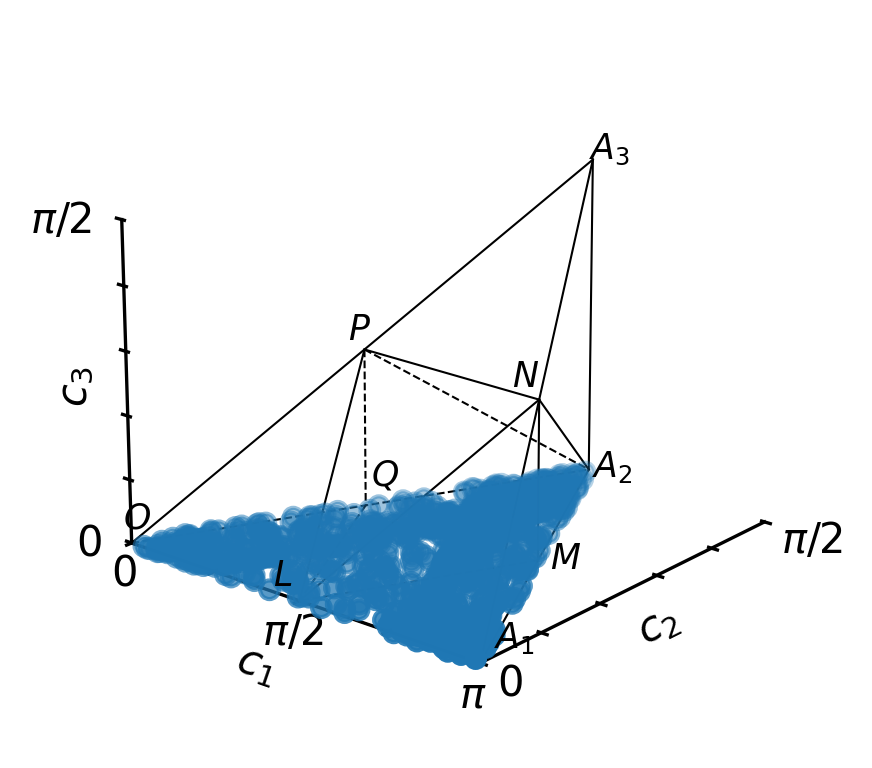

In [95]:
from numpy.random import uniform
from weylchamber import WeylChamber

alpha = 1
theta_targ = np.pi * alpha
omega_targ = np.pi
phi_targ = np.pi / 2
rand_pd_basis_gate = lambda: parallel_drive_CR(
    # theta=uniform((0) * theta_targ, (2) * theta_targ),
    theta=theta_targ,
    omega_1=uniform((0) * omega_targ, (2) * omega_targ),
    omega_2=uniform((0) * omega_targ, (2) * omega_targ),
)

w = WeylChamber()
for _ in range(N := 1_000):
    w.add_point(*c1c2c3(rand_pd_basis_gate()))
w.plot()

# print(c1c2c3(CR()))
# print(c1c2c3(parallel_drive_CR()))

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 5.096000000000001e-12
             x: [ 2.025e+00  1.927e+00]
           nit: 185
          nfev: 343
 final_simplex: (array([[ 2.025e+00,  1.927e+00],
                       [ 2.025e+00,  1.927e+00],
                       [ 2.025e+00,  1.927e+00]]), array([ 5.096e-12,  5.124e-12,  5.130e-12]))

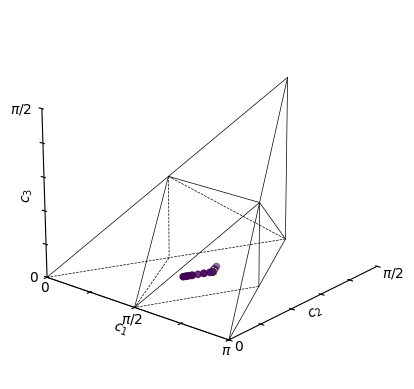

In [125]:
alpha = 0.75
target_gate = iSwapGate().power(alpha).to_matrix()

target_gate = BGate().to_matrix()

target_coords = list(c1c2c3(target_gate))
if target_coords[0] > 0.5:
    target_coords[0] = 1 - target_coords[0]


def cr_objective(x0):
    U = parallel_drive_CR(
        theta=np.pi * alpha,
        omega_1=x0[0],
        omega_2=x0[1],
    )
    c1, c2, c3 = c1c2c3(U)
    if c1 > 0.5:
        c1 = 1 - c1
    coordinate_iteration_list.append((c1, c2, c3))
    return J_T_LI(U, target_gate)


x0 = [np.pi / 2, np.pi / 2]
coordinate_iteration_list = []
result = minimize(cr_objective, x0, method="Nelder-Mead")
display(result)


# callback method in ClosestInvariantSearch saves the intermediate points
ax = plt.subplot(111, projection="3d", computed_zorder=False)
idx = 2
colors = cm.viridis(np.linspace(0, 1.0, len(coordinate_iteration_list)))
w = WeylChamber()
w.labels = {}
w.render(ax)
w.ax.scatter3D(*zip(*coordinate_iteration_list), color=colors, zorder=-1)